##1. Target:  GW231123 (~223M⊙)

Link to press release: https://arxiv.org/abs/2508.18083

In [ ]:
! pip install -q 'gwosc==0.7.1'

In [ ]:
import gwosc
print(gwosc.__version__)

0.7.1


In [ ]:
from gwosc.datasets import find_datasets
from gwosc import datasets

print("Current list of available catalogs")
print(find_datasets(type="catalog"))

Current list of available catalogs
['GWTC', 'GWTC-1-confident', 'GWTC-1-marginal', 'GWTC-2', 'GWTC-2.1-auxiliary', 'GWTC-2.1-confident', 'GWTC-2.1-marginal', 'GWTC-3-confident', 'GWTC-3-marginal', 'GWTC-4.0', 'IAS-O3a', 'Initial_LIGO_Virgo', 'O1_O2-Preliminary', 'O3_Discovery_Papers', 'O3_IMBH_marginal', 'O4_Discovery_Papers']


In [ ]:
gwtc4 = datasets.find_datasets(type='events', catalog='GWTC-4-confident')
print('GWTC-4 events:', gwtc4)
print("")

GWTC-4 events: []



In [ ]:
from gwosc.datasets import event_gps
gps = event_gps('GW231123')
print(gps)

from gwosc.datasets import event_at_gps
print(datasets.event_at_gps(1384782888))

1384782888.7
GW231123_135430


In [ ]:
from gwosc import urls
from gwosc.locate import get_event_urls
urls = get_event_urls('GW231123')
print(urls)

['https://gwosc.org/archive/data/O4a_4KHZ_R1/1384120320/H-H1_GWOSC_O4a_4KHZ_R1-1384779776-4096.hdf5', 'https://gwosc.org/archive/data/O4a_4KHZ_R1/1384120320/L-L1_GWOSC_O4a_4KHZ_R1-1384779776-4096.hdf5']


In [ ]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [ ]:
! pip install -q 'gwpy==3.0.12'

In [ ]:
import gwpy
print(gwpy.__version__)

3.0.12


`[start, end)` GPS segment to 20 seconds around this time


In [ ]:
segment = (int(gps)-10, int(gps)+10)
print(segment)

(1384782878, 1384782898)


In [ ]:
from gwpy.timeseries import TimeSeries
ldata = TimeSeries.fetch_open_data('L1', *segment, verbose = True, cache = True)
print(ldata)

Fetched 1 URLs from gwosc.org for [1384782878 .. 1384782898))
Reading data... [Done]
TimeSeries([2.46611756e-19, 2.32727380e-19, 2.15231112e-19, ...,
            1.22161409e-18, 1.23945318e-18, 1.25745564e-18]
           unit: dimensionless,
           t0: 1384782878.0 s,
           dt: 0.000244140625 s,
           name: Strain,
           channel: None)


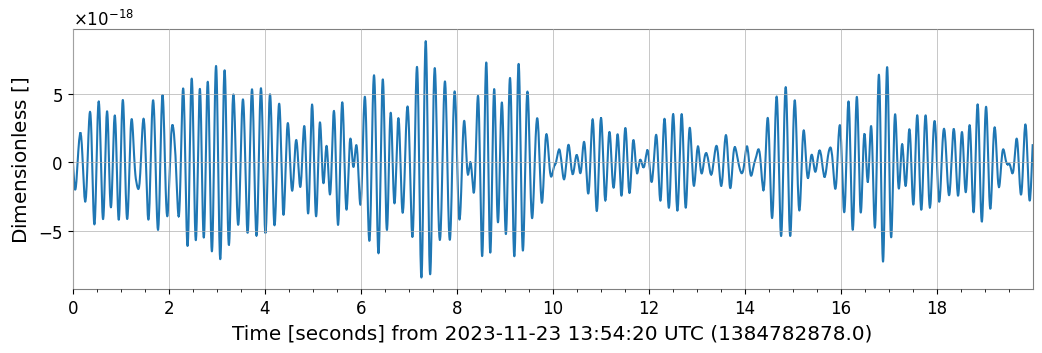

In [ ]:
plot = ldata.plot()

Calculating Fourier Transform of our TimeSeries

In [ ]:
fft = ldata.fft()
print(fft)

FrequencySeries([-6.17215829e-21+0.00000000e+00j,
                 -1.23452508e-20-2.65762809e-23j,
                 -1.23482842e-20-5.50161309e-23j, ...,
                 -1.23839607e-23+1.40009357e-26j,
                 -1.23941871e-23+1.67774825e-26j,
                 -1.23932402e-23+0.00000000e+00j]
                unit: dimensionless,
                f0: 0.0 Hz,
                df: 0.05 Hz,
                epoch: 1384782878.0,
                name: Strain,
                channel: None)


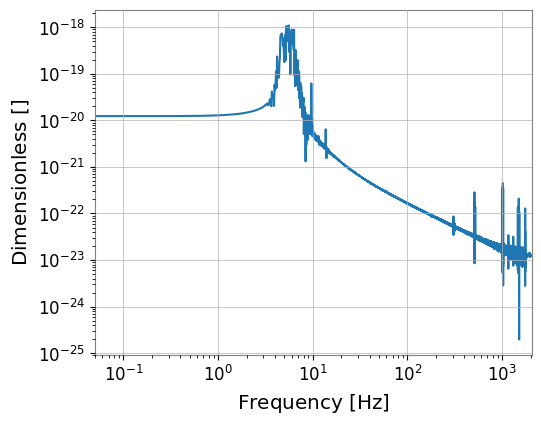

In [ ]:
from scipy.signal import get_window
window = get_window('hann', ldata.size)
lwin = ldata * window
fftamp = lwin.fft().abs()
plot = fft.abs().plot(xscale="log", yscale="log")
plot.show(warn=False)

Fluctuations in above plot >10 Hz seem random. This is intrinsic noise in the estimate of the spectral content of the signal from a single FFT. Reduce these fluctuations by averaging many estimates of the signal FFT; want to average are their squared moduli to find their Power Spectral Density (PSD).

Linnk to Spectral Density Guide: https://en.wikipedia.org/wiki/Spectral_density

Link to Welch's Method: https://en.wikipedia.org/wiki/Welch%27s_method

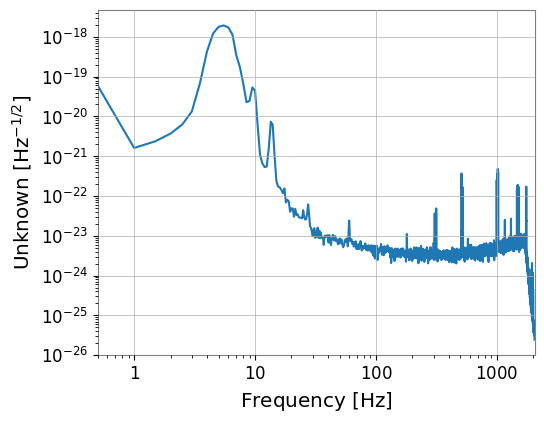

In [ ]:
asd = ldata.asd(fftlength=2, method="median")
plot = asd.plot()
plot.show(warn=False)

zooming in the frequency zone of interest

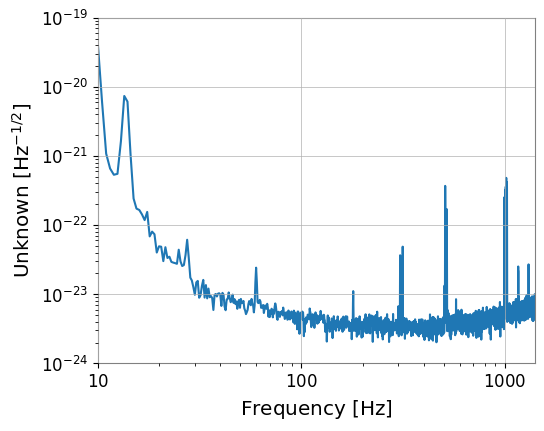

In [ ]:
ax = plot.gca()
ax.set(xlim=(10, 1400), ylim=(1e-24, 1e-19))
plot

notable spikes:
*   ~80 Hz
*   ~200 Hz
*   ~400 Hz
*   ~1000 Hz


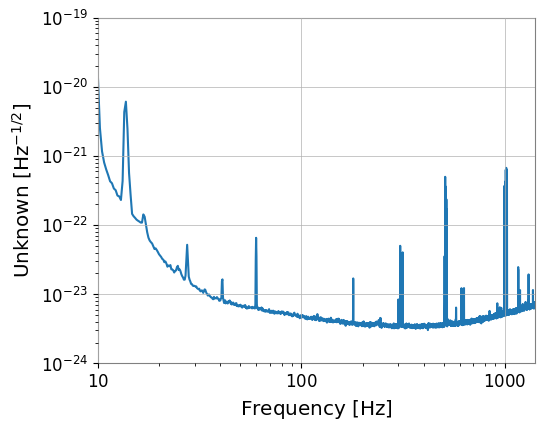

In [ ]:
ldata2 = TimeSeries.fetch_open_data('L1', int(gps)-512, int(gps)+512, cache=True)
lasd2 = ldata2.asd(fftlength=4, method="median")
plot = lasd2.plot()
ax = plot.gca()
ax.set_xlim(10, 1400)
ax.set_ylim(1e-24, 1e-19)
plot.show(warn=False)

notable spikes:
*   ~80 Hz
*   ~300 Hz
*   ~500 Hz
*   ~580 Hz
*   ~610 Hz
*   ~1000 Hz

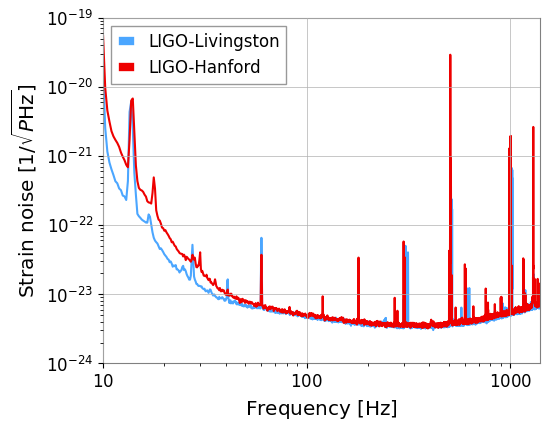

In [ ]:
#Hanford Data
hdata2 = TimeSeries.fetch_open_data('H1', int(gps)+512, int(gps)-512, cache=True)
hasd2 = hdata2.asd(fftlength=4, method="median")

#Virgo Data
#vdata2 = TimeSeries.fetch_open_data('V1', int(gps)+512, int(gps)-512, cache=True)
#vasd2 = vdata2.asd(fftlength=4, method="median")

#plot w/ standard colors
ax.plot(hasd2, label='LIGO-Hanford', color='gwpy:ligo-hanford')
#ax.plot(vasd, label='Virgo', color='gwpy:virgo')

#label and recolor Livingston Data
lline = ax.lines[0]
lline.set_color('gwpy:ligo-livingston')
lline.set_label('LIGO-Livingston')

ax.set_ylabel(r'Strain noise [$1/\sqrt{P\mathrm{Hz}}$]')
ax.legend()
plot

To note: Virgo data not currently available for this event.

In [ ]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [ ]:
from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries

gps = event_gps('GW231123')
print("GW231123 GPS:", gps)

ldata = TimeSeries.fetch_open_data('L1', int(gps)-512, int(gps)+512, cache=True)
print("GW231123 data")
print(ldata)

GW231123 GPS: 1384782888.7
GW231123 data
TimeSeries([ 9.38934447e-19,  9.41937371e-19,  9.45239671e-19,
            ..., -2.73950547e-18, -2.75777708e-18,
            -2.78169559e-18]
           unit: dimensionless,
           t0: 1384782376.0 s,
           dt: 0.000244140625 s,
           name: Strain,
           channel: None)


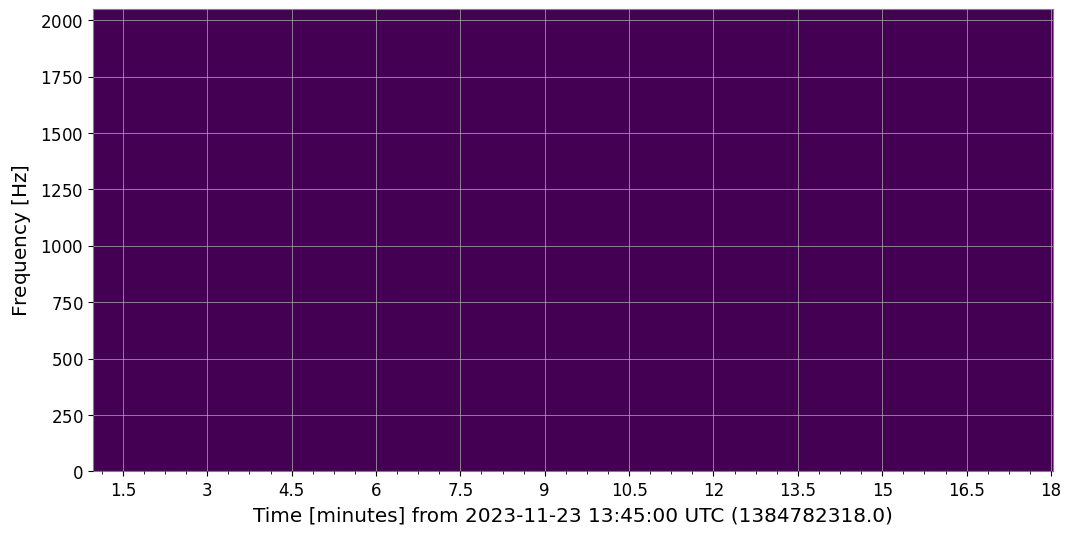

In [ ]:
specgram = ldata.spectrogram2(fftlength=4, overlap=2, window='hann') ** (1/2.)
plot = specgram.plot()

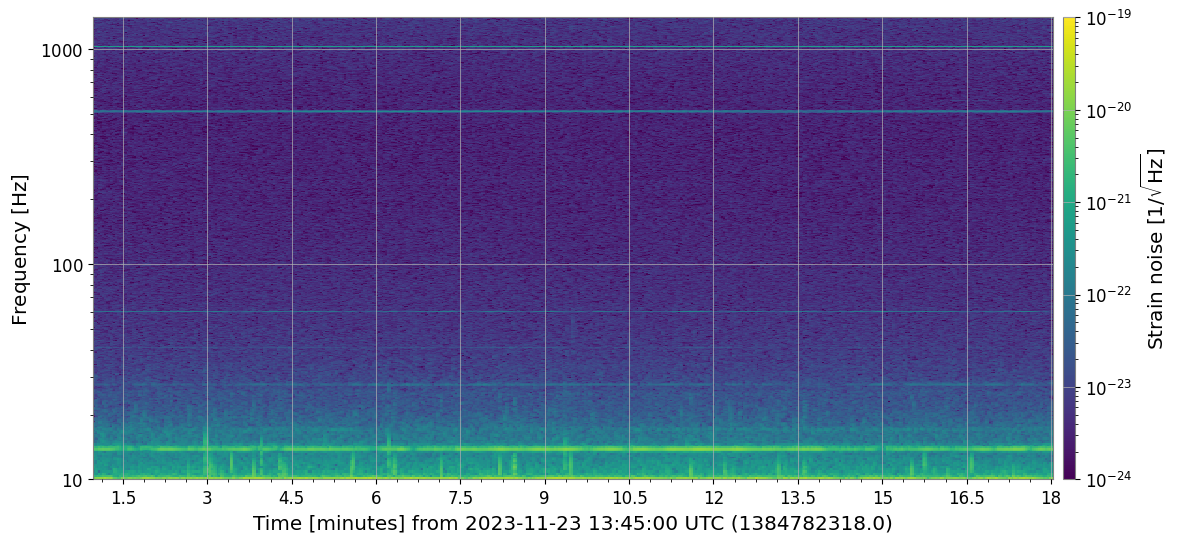

In [ ]:
ax = plot.gca()
ax.set_yscale('log')
ax.set_ylim(10, 1400)
ax.colorbar(
    clim=(1e-24, 1e-19),
    norm="log",
    label=r"Strain noise [$1/\sqrt{\mathrm{Hz}}$]",
)
plot

some noise noted between 30-100 Hz. Non-stationary noise.

Fetched 1 URLs from gwosc.org for [1384782858 .. 1384782908))
Reading data... [Done]


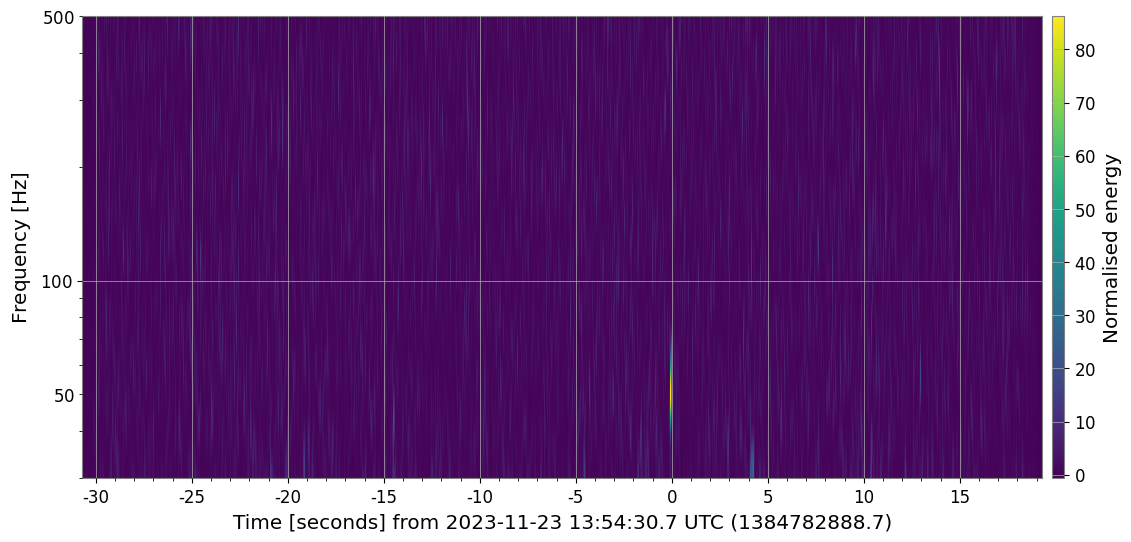

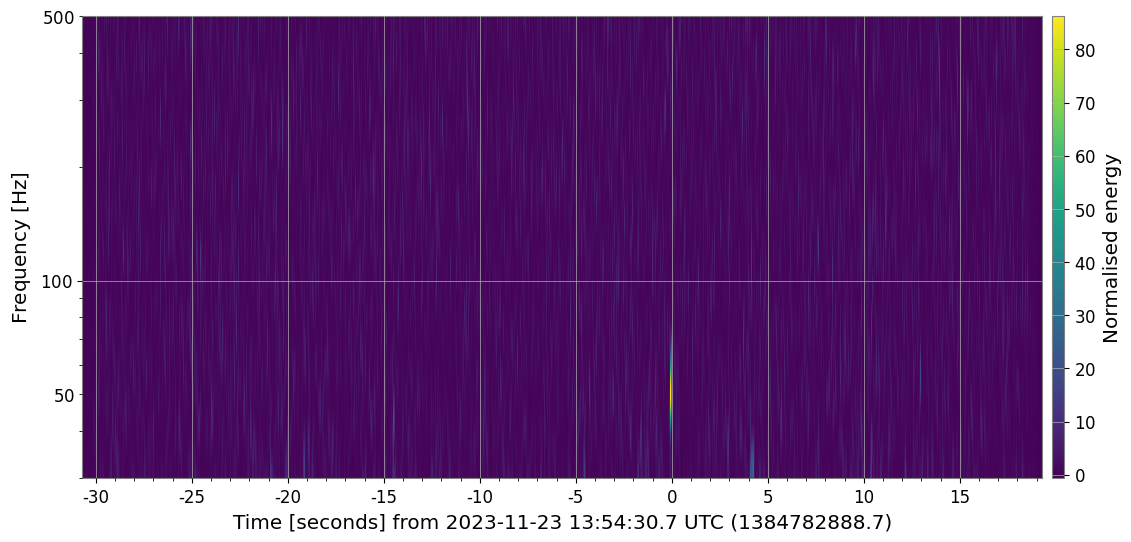

In [ ]:
segment = (int(gps) - 30, int(gps) + 20)
hdata = TimeSeries.fetch_open_data('H1', *segment, verbose=True, cache=True)

hq = hdata.q_transform(frange=(30, 500))
plot = hq.plot()
plot.colorbar(label="Normalised energy")

ax = plot.gca()
ax.set_epoch(gps)
ax.set_ylim(30, 500)
ax.set_yscale("log")
plot

notable features at ~-14sec, ~0sec, and ~4sec

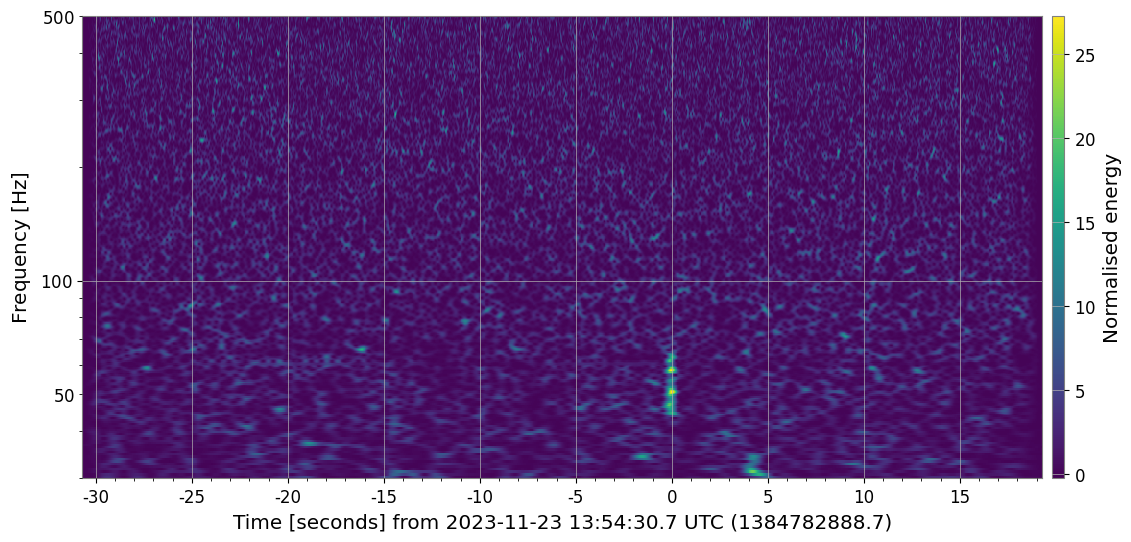

In [ ]:
hq = hdata.q_transform(frange=(30, 500), qrange=(100, 110))
plot = hq.plot()
ax = plot.gca()
ax.set_epoch(gps)
ax.set_yscale('log')
ax.colorbar(label="Normalised energy")

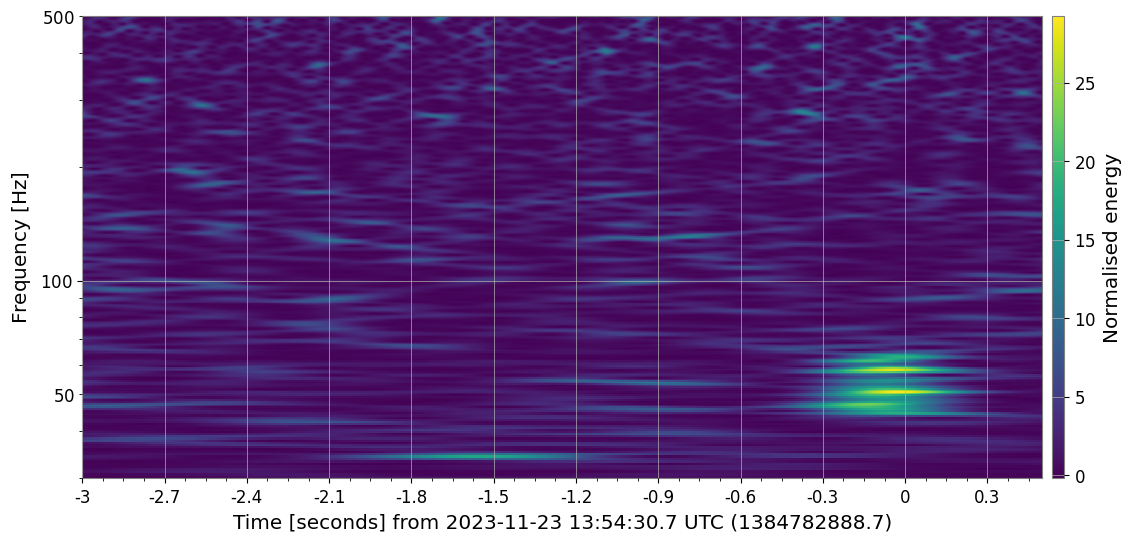

In [ ]:
hq2 = hdata.q_transform(frange=(30,500), qrange=(80, 110), outseg=(gps-3,gps+0.5))
plot = hq2.plot()
ax = plot.gca()
ax.set_epoch(gps)
ax.set_yscale('log')
ax.colorbar(label="Normalised energy")

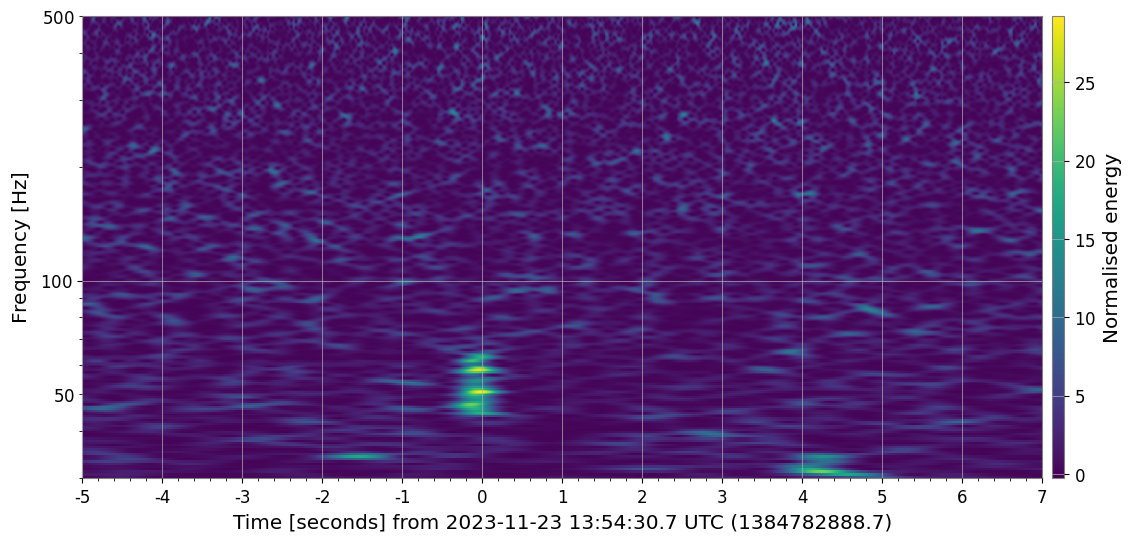

In [ ]:
hq2 = hdata.q_transform(frange=(30,500), qrange=(80, 110), outseg=(gps-5,gps+7))
plot = hq2.plot()
ax = plot.gca()
ax.set_epoch(gps)
ax.set_yscale('log')
ax.colorbar(label="Normalised energy")

NOTE: outseg intended to zoom in around merger, not currently working. (Ask Hughes)

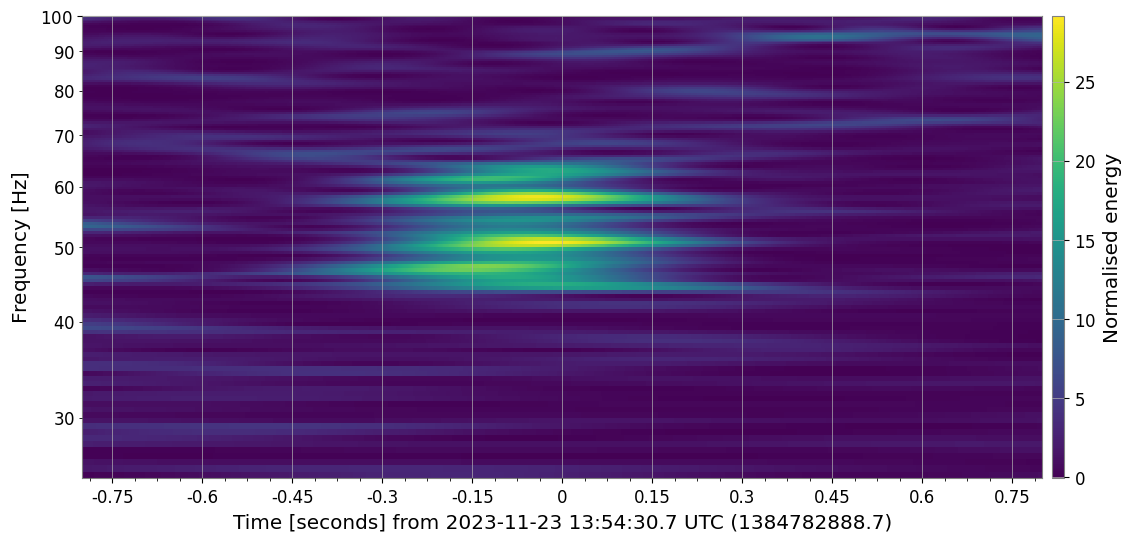

In [ ]:
hq2 = hdata.q_transform(frange=(25,100), qrange=(80, 110), outseg=(gps-0.8,gps+0.8))
plot = hq2.plot()
ax = plot.gca()
ax.set_epoch(gps)
ax.set_yscale('log')
ax.colorbar(label="Normalised energy")

Fetched 1 URLs from gwosc.org for [1384782858 .. 1384782908))
Reading data... [Done]


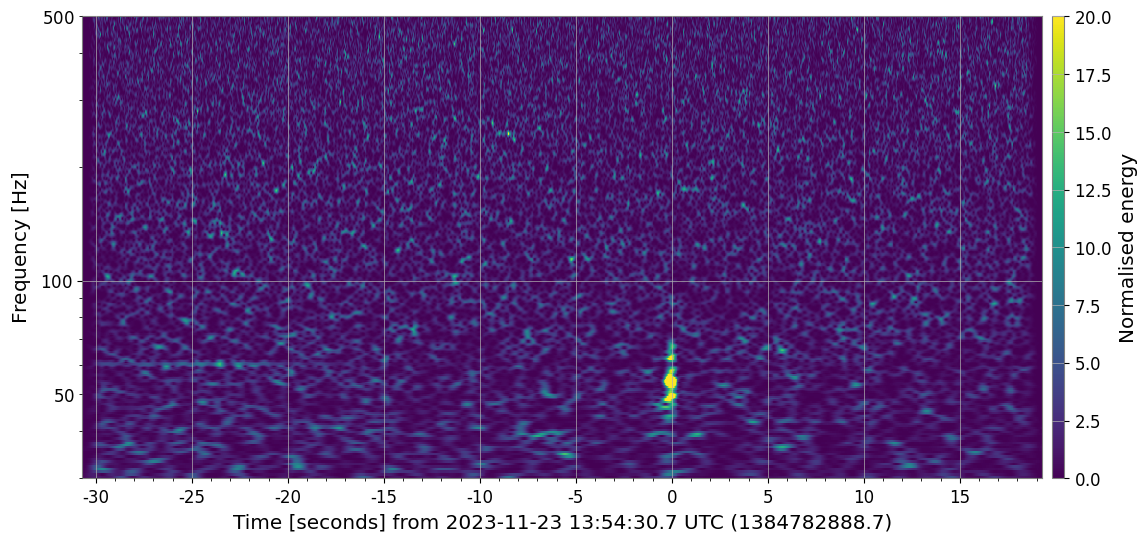

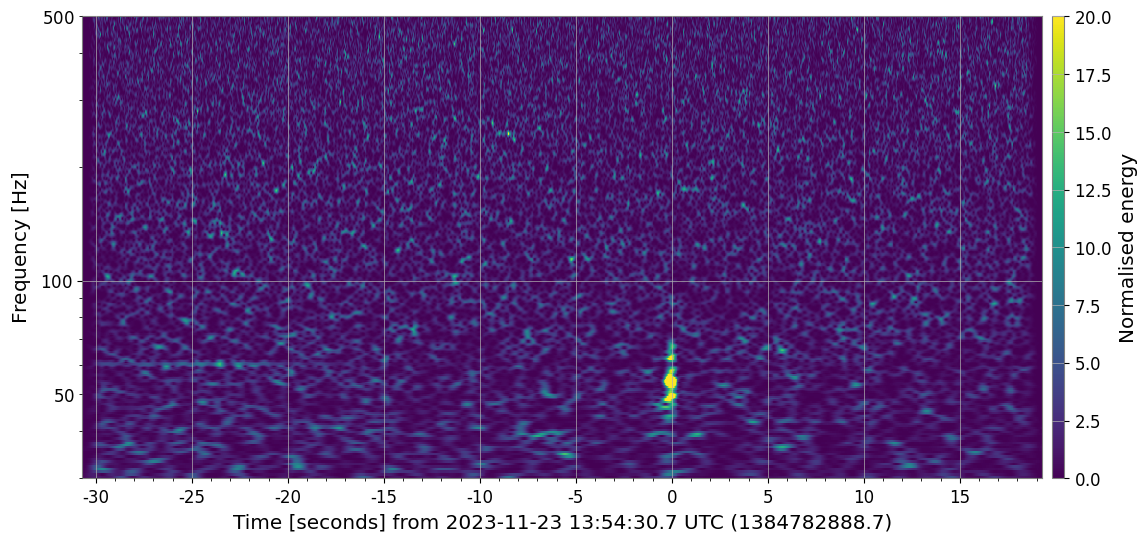

In [ ]:
ldata = TimeSeries.fetch_open_data('L1', *segment, verbose=True)
lq = ldata.q_transform(frange=(30, 500), qrange=(100,110))
plot = lq.plot()
ax = plot.gca()
ax.set_epoch(gps)
ax.set_yscale('log')
ax.colorbar(label="Normalised energy")

plot.colorbars[0].mappable.set_clim(0,20)
plot

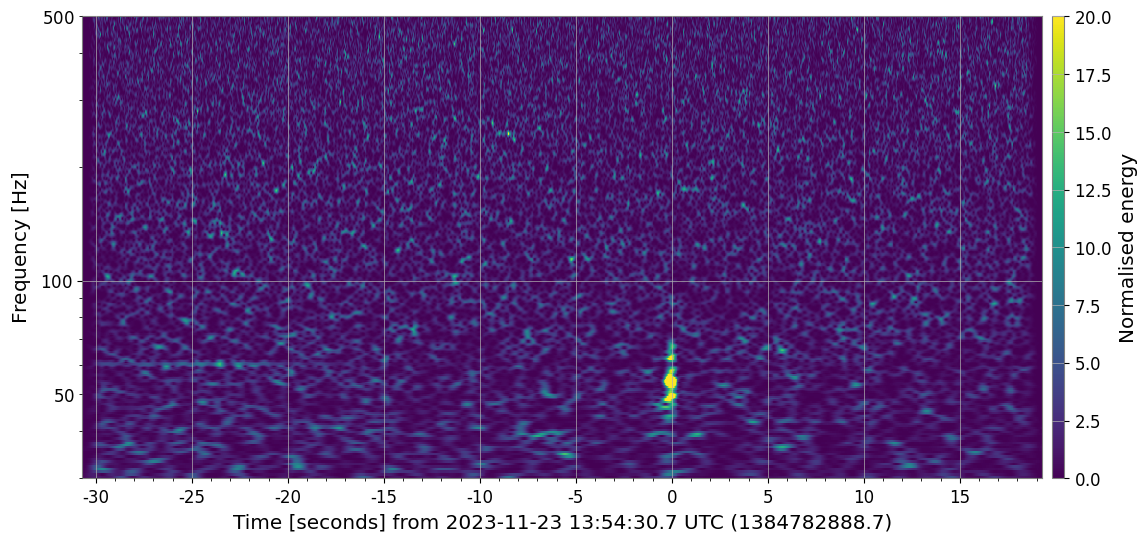

In [ ]:
gated_ldata = ldata.gate(tzero=0.25, tpad=0.25)

gated_lq = gated_ldata.q_transform(frange=(30, 500), qrange=(100,110))
plot = gated_lq.plot()
ax = plot.gca()
ax.set_epoch(gps)
ax.set_yscale('log')
ax.colorbar(label="Normalised energy")
plot.colorbars[0].mappable.set_clim(0,20)

# Generating Waveforms

In [ ]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [ ]:
! pip install -q PyCBC==2.4.1 lalsuite==7.25

In [ ]:
from pycbc.waveform import get_td_waveform, fd_approximants
import matplotlib.pyplot as plt

In [ ]:
from pycbc.waveform import td_approximants

In [ ]:
print('Time domain waveforms: ', td_approximants())
print('Frequency domain waveforms: ', fd_approximants())

Time domain waveforms:  ['TaylorT1', 'TaylorT2', 'TaylorT3', 'SpinTaylorT1', 'SpinTaylorT4', 'SpinTaylorT5', 'PhenSpinTaylor', 'PhenSpinTaylorRD', 'EOBNRv2', 'EOBNRv2HM', 'TEOBResum_ROM', 'SEOBNRv1', 'SEOBNRv2', 'SEOBNRv2_opt', 'SEOBNRv3', 'SEOBNRv3_pert', 'SEOBNRv3_opt', 'SEOBNRv3_opt_rk4', 'SEOBNRv4', 'SEOBNRv4_opt', 'SEOBNRv4P', 'SEOBNRv4PHM', 'SEOBNRv2T', 'SEOBNRv4T', 'SEOBNRv4_ROM_NRTidalv2', 'SEOBNRv4_ROM_NRTidalv2_NSBH', 'HGimri', 'IMRPhenomA', 'IMRPhenomB', 'IMRPhenomC', 'IMRPhenomD', 'IMRPhenomD_NRTidalv2', 'IMRPhenomNSBH', 'IMRPhenomHM', 'IMRPhenomPv2', 'IMRPhenomPv2_NRTidal', 'IMRPhenomPv2_NRTidalv2', 'TaylorEt', 'TaylorT4', 'EccentricTD', 'SpinDominatedWf', 'NR_hdf5', 'NRSur7dq2', 'NRSur7dq4', 'SEOBNRv4HM', 'NRHybSur3dq8', 'IMRPhenomXAS', 'IMRPhenomXHM', 'IMRPhenomPv3', 'IMRPhenomPv3HM', 'IMRPhenomXP', 'IMRPhenomXPHM', 'TEOBResumS', 'IMRPhenomT', 'IMRPhenomTHM', 'IMRPhenomTP', 'IMRPhenomTPHM', 'SEOBNRv4HM_PA', 'pSEOBNRv4HM_PA', 'IMRPhenomXAS_NRTidalv2', 'IMRPhenomXP_NRTidal

In [ ]:
plt.figure(figsize=plt.figaspect(0.4))
for m in [137, 101, 223, ?]
  hp,hc = get_td_waveform(approximant="IMRPhenomD",
                          mass1=m,
                          mass2=m,
                          delta_t=1.0/4096,
                          f_lower=223)
  plt.plot(hp.sample_times, hp, label='$M_{\odot 1,2}=%s$' % m)
plt.legend()
plt.grid